In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# add code directory to path
import sys
import os
sys.path.append(os.path.join(os.path.abspath(''), 'code'))

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [4]:
from config import load_config
from bootstrap import get_oh_table
from clustering import cluster_embeddings

In [5]:
from tempfile import TemporaryDirectory

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [7]:
config = load_config("configs/config_PTE.yaml", args=["--opmode", "mean"])
sequences_df = pd.read_csv(config["dataset_path"])
wt_seq = sequences_df.loc[0]
mean_embeddings_with_wt = np.load(config["embeddings_path"])

config = load_config("configs/config_original_paper.yaml", args=["--opmode", "flat"])
flat_embeddings_with_wt = np.load(config["embeddings_path"])

['--opmode', 'mean']
Loaded configuration:
  root_path: /home/labs/fleishman/omripo/Projects/adaptive_learning

  data_dir_name: data

  pretraining_dir_name: pretraining

  bootstrap_dir_name: bootstrap

  results_dir_name: results

  enzyme: PTE

  substrate: malathion

  dataset_filename: adaptive_learning_stage_0.csv

  tag: adaptive

  weights_filename: final_model.pt

  model_type: plm

  finetune: False

  opmode: mean

  train_type: msa_backbone

  cluster_method: spherical_kmeans

  nmuts_column: num_muts

  sequence_column_name: full_seq

  activity_column_name: inactive

  first_column_name: I106

  last_column_name: M317

  plm_name: esm2_t12_35M_UR50D

  ref_seq: DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALAEKAVRGLRRARAAGVRTIVDVSTFDIGRDVSLLAEVSRAADVHIVAATGLWFDPPLSMRLRSVEELTQFFLREIQYGIEDTGIRAGIIKVATTGKATPFQELVLKAAARASLATGVPVTTHTAASQRDGEQQAAIFESEGLSPSRVCIGHSDDTDDLSYLTALAARGYLIGLDHIPHSAIGLEDNASASALLGIRSWQTRALLIKALIDQGYMKQILVSNDWLFGFSSYVTNIMDVMDRVNPDGMAFIPLRVIPFLREKGVPQETLAGI

In [8]:
wt_mean_emb = mean_embeddings_with_wt[0]
wt_flat_emb = flat_embeddings_with_wt[0]

mean_delta_embeddings = mean_embeddings_with_wt - wt_mean_emb
flat_delta_embeddings = flat_embeddings_with_wt - wt_flat_emb
assert (mean_delta_embeddings[0] == np.zeros_like(wt_mean_emb)).all()
assert (flat_delta_embeddings[0] == np.zeros_like(wt_flat_emb)).all()

# drop the wt row
mean_embeddings = mean_embeddings_with_wt[1:]
flat_embeddings = flat_embeddings_with_wt[1:]
mean_delta_embeddings = mean_delta_embeddings[1:]
flat_delta_embeddings = flat_delta_embeddings[1:]

In [10]:
experimental_results = pd.read_csv(f"{config["data_dir_path"]}/experimental_results.csv")

In [11]:
substrate = "p-nitrophenyl_octanoate"
y = np.log(experimental_results[substrate] + 1e-8)
y_bin = y >= 1
y.shape

(49,)

In [56]:
experimental_results[substrate]

0      12.02
1      40.62
2       3.64
3       1.76
4       3.44
5      48.20
6       0.22
7      77.02
8       0.18
9       0.00
10      3.54
11     15.46
12      0.78
13      1.88
14      0.32
15      0.12
16      0.14
17      0.22
18      0.32
19      0.58
20      0.00
21     25.62
22      2.48
23     10.30
24    116.14
25      5.62
26     24.62
27     41.26
28      3.44
29    149.72
30     85.94
31      3.64
32      1.38
33     21.08
34      2.92
35      2.34
36      5.26
37      0.44
38      0.26
39      8.22
40      0.00
41      7.82
42      0.62
43      2.48
44      0.00
45      0.62
46      1.88
47     31.78
48      1.02
Name: p-nitrophenyl_octanoate, dtype: float64

In [12]:
# calculate chance level accuracy
chance_acc = max(y_bin.mean(), 1 - y_bin.mean())
# calculate chance level precision, recall, f1
chance_prec = y_bin.sum() / len(y_bin)
chance_rec = y_bin.mean()
chance_f1 = 2 * (chance_prec * chance_rec) / (chance_prec + chance_rec)

In [228]:
n_clusters = 11

In [229]:
defs = [{"embeddings": mean_embeddings, "emb_type": "mean", "cluster_method": "kmeans"},
        {"embeddings": flat_embeddings, "emb_type": "flat", "cluster_method": "kmeans"},
        {"embeddings": mean_delta_embeddings, "emb_type": "mean_delta", "cluster_method": "kmeans"},
         {"embeddings": flat_delta_embeddings, "emb_type": "flat_delta", "cluster_method": "kmeans"},
         {"embeddings": mean_embeddings, "emb_type": "mean", "cluster_method": "spherical_kmeans"},
        {"embeddings": flat_embeddings, "emb_type": "flat", "cluster_method": "spherical_kmeans"},
        {"embeddings": mean_delta_embeddings, "emb_type": "mean_delta", "cluster_method": "spherical_kmeans"},
         {"embeddings": flat_delta_embeddings, "emb_type": "flat_delta", "cluster_method": "spherical_kmeans"},
        ]

In [230]:
for d in defs:
    with TemporaryDirectory() as tmpdir:
        print(f"Clustering {d['emb_type']} embeddings with {d['cluster_method']}")
        labels, rep_indices = cluster_embeddings(d["embeddings"], 
                                                 n_clusters=n_clusters, 
                                                 save_path=f"{tmpdir}/tmp_clusters.npy", 
                                                 spherical=(d["cluster_method"]=="spherical_kmeans"))
        print(f"Cluster labels: {labels}")
        d["cluster_labels"] = labels
        d["representative_indices"] = rep_indices

Clustering mean embeddings with kmeans
Cluster labels: [ 2  2  7  7  9  3  4  6  4  4  6  0  9  2  4  6  6  0  0  6  2  1  5  9
  5 10 10  7  7  1  2  8 10 10  3  3  1  5  5  5  9  7  9  5  8  9  3  3
  9]
Clustering flat embeddings with kmeans
Cluster labels: [ 8  8  8  8  4 10  7  4  7  7  8  0  7  5  2  5  5  0  0  5  5  5  6  3
  6  3  3  0  0  3  2  3  3  3  9  9  1  6  6  2  1  2  9  2  7  3  2 10
  9]
Clustering mean_delta embeddings with kmeans
Cluster labels: [ 2  2  7  7  9  3  4  6  4  4  6  0  9  2  4  6  6  0  0  6  2  1  5  9
  5 10 10  7  7  1  2  8 10 10  3  3  1  5  5  5  9  7  9  5  8  9  3  3
  9]
Clustering flat_delta embeddings with kmeans
Cluster labels: [ 8  8  8  8  4 10  7  4  7  7  8  0  7  5  2  5  5  0  0  5  5  5  6  3
  6  3  3  0  0  3  2  3  3  3  9  9  1  6  6  2  1  2  9  2  7  3  2 10
  9]
Clustering mean embeddings with spherical_kmeans
Cluster labels: [ 4  4  5  5 10  3  6 10  9  9  4  5  6  2 10  0  0  4  5  0 10  1  2  1
 10  7  1  8  5  7  4  6  

In [231]:
# build classifier from each clustering result
for d in defs:
    for i in range(n_clusters):
        cluster_indices = np.where(d["cluster_labels"] == i)[0]
        cluster_y_bin = y_bin.iloc[cluster_indices]
        # choose majority class as cluster prediction
        majority_class = cluster_y_bin.value_counts().idxmax()
        d.setdefault("cluster_majority_classes", []).append(majority_class)
# evaluate accuracy
for d in defs:
    y_pred = np.array([d["cluster_majority_classes"][label] for label in d["cluster_labels"]])
    # create confusion matrix
    cm = confusion_matrix(y_bin, y_pred)
    acc = accuracy_score(y_bin, y_pred)
    prec = precision_score(y_bin, y_pred)
    rec = recall_score(y_bin, y_pred)
    f1 = f1_score(y_bin, y_pred)
    d["cm"] = cm
    d["accuracy"] = acc
    d["precision"] = prec
    d["recall"] = rec
    d["f1"] = f1

In [232]:
d["cluster_majority_classes"]

[np.True_,
 np.False_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.False_,
 np.True_,
 np.False_,
 np.True_,
 np.False_]

In [233]:
defs[5]["cm"]

array([[18,  7],
       [ 5, 19]])

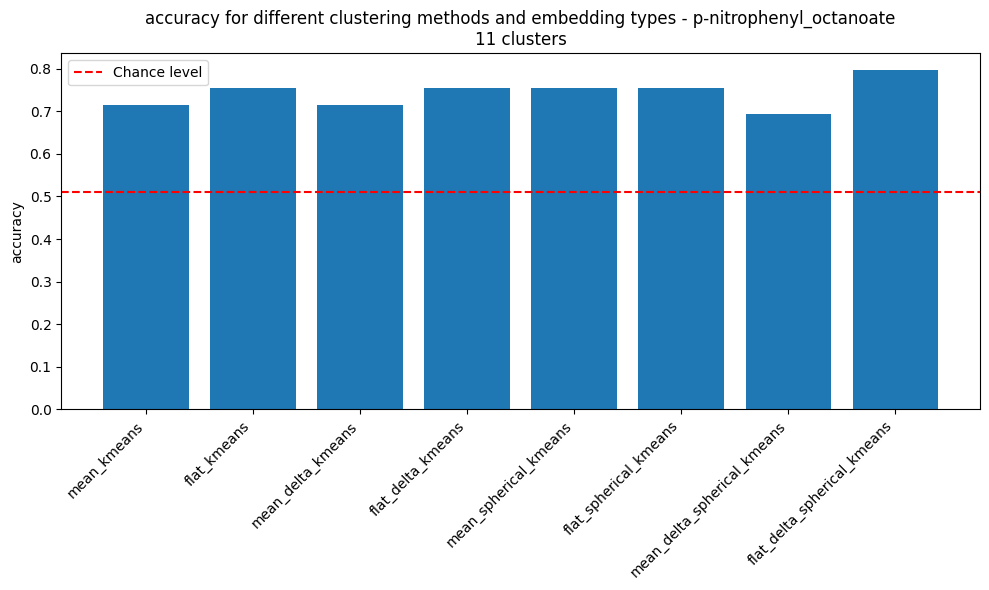

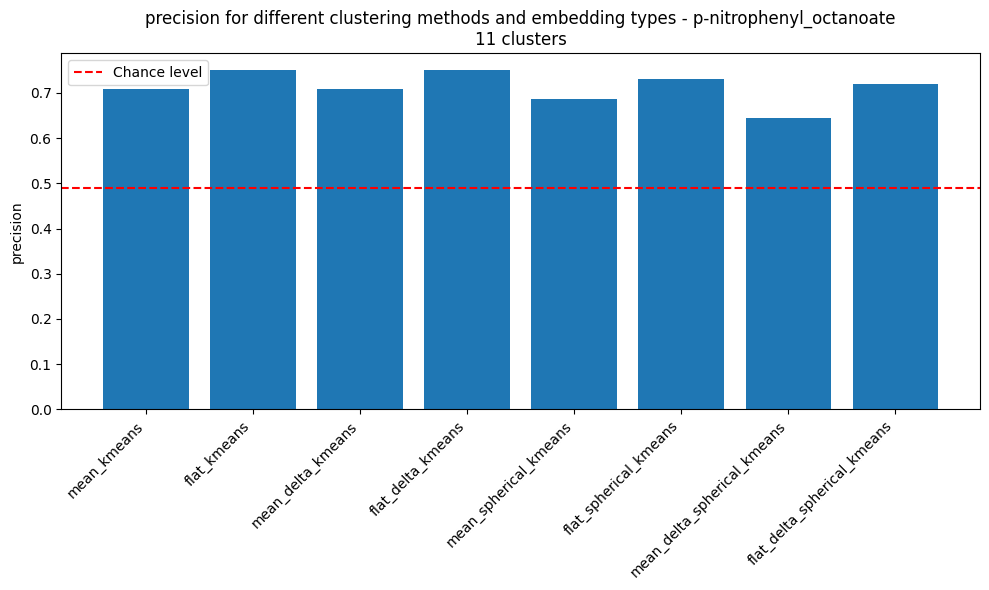

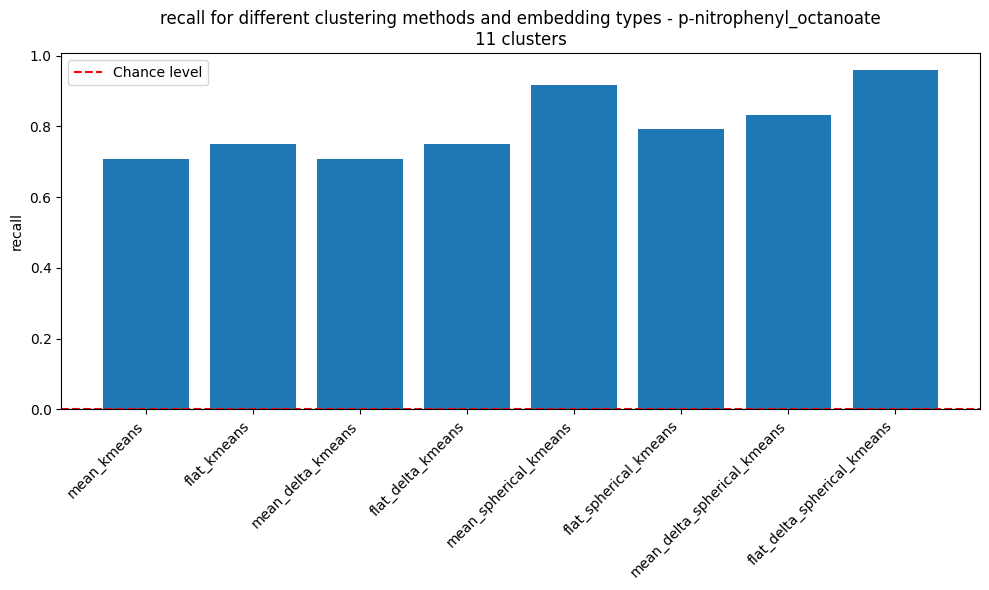

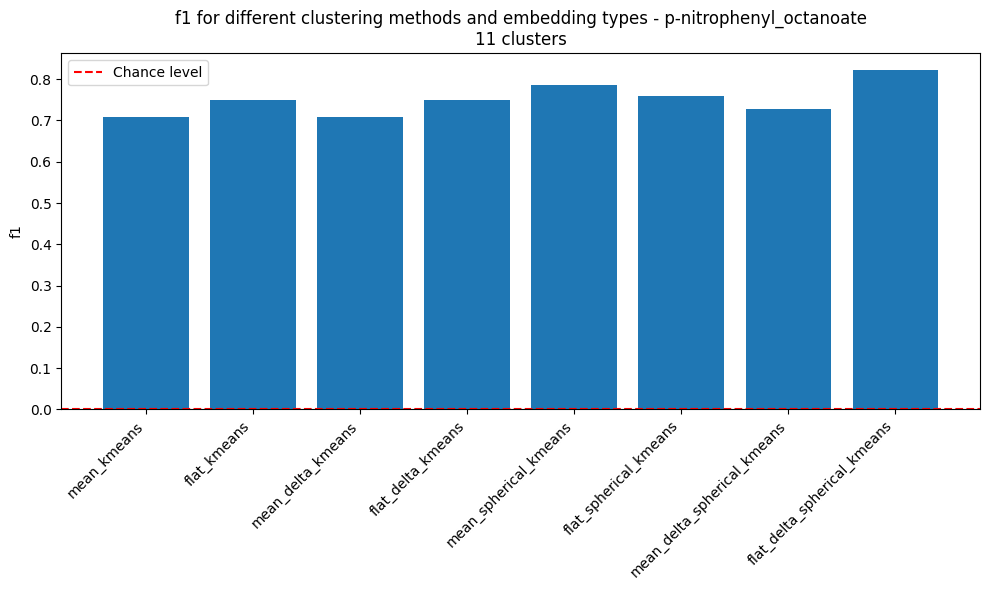

In [234]:
accuracies = [d["accuracy"] for d in defs]
precisions = [d["precision"] for d in defs]
recalls = [d["recall"] for d in defs]
f1s = [d["f1"] for d in defs]

# plot bar charts of each metric
metrics = {"accuracy": accuracies, "precision": precisions, "recall": recalls, "f1": f1s}
chance_levels = {"accuracy": chance_acc, "precision": chance_prec}
for metric_name, metric_values in metrics.items():
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(defs)), metric_values)
    plt.xticks(range(len(defs)), [f"{d['emb_type']}_{d['cluster_method']}" for d in defs], rotation=45, ha='right')
    plt.ylabel(metric_name)
    plt.axhline(y=chance_levels.get(metric_name, 0), color='r', linestyle='--', label='Chance level')
    plt.legend()
    plt.title(f"{metric_name} for different clustering methods and embedding types - {substrate}\n{n_clusters} clusters")
    plt.tight_layout()
    plt.show()

In [5]:
config = load_config("configs/config_PTE.yaml")

Loaded configuration:
  root_path: /home/labs/fleishman/omripo/Projects/adaptive_learning

  data_dir_name: data

  pretraining_dir_name: pretraining

  bootstrap_dir_name: bootstrap

  results_dir_name: results

  enzyme: PTE

  substrate: malathion

  dataset_filename: adaptive_learning_stage_0.csv

  tag: adaptive

  weights_filename: final_model.pt

  model_type: plm

  finetune: False

  opmode: mean

  train_type: msa_backbone

  cluster_method: spherical_kmeans

  nmuts_column: num_muts

  sequence_column_name: full_seq

  activity_column_name: inactive

  first_column_name: I106

  last_column_name: M317

  plm_name: esm2_t12_35M_UR50D

  ref_seq: DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALAEKAVRGLRRARAAGVRTIVDVSTFDIGRDVSLLAEVSRAADVHIVAATGLWFDPPLSMRLRSVEELTQFFLREIQYGIEDTGIRAGIIKVATTGKATPFQELVLKAAARASLATGVPVTTHTAASQRDGEQQAAIFESEGLSPSRVCIGHSDDTDDLSYLTALAARGYLIGLDHIPHSAIGLEDNASASALLGIRSWQTRALLIKALIDQGYMKQILVSNDWLFGFSSYVTNIMDVMDRVNPDGMAFIPLRVIPFLREKGVPQETLAGITVTNPARFLSPTLRAS

  b

In [ ]:
if config.get("delta_embeddings", False):
        delta_embedding_tag = "delta_embeddings"
else:
        delta_embedding_tag = "regular_embeddings"
representatives_df_path = f"{config['results_path']}/cluster_representative_sequences_{config['opmode']}_{config['finetune_tag']}_{config['cluster_method']}_{delta_embedding_tag}.csv"
representatives_df = pd.read_csv(representatives_df_path)

In [14]:
# Add a column named "design" that starts with 0 and increments by 1 for each row
representatives_df["design"] = range(len(representatives_df))
# make it the first column
cols = representatives_df.columns.tolist()
cols = cols[-1:] + cols[:-1]
representatives_df = representatives_df[cols]
# set it as the index
representatives_df.set_index("design", inplace=True)

In [15]:
representatives_df

,serial_number,I106,F132,H254,H257,L271,L303,F306,M317,num_muts,full_seq,score,inactive,pad_regions
design,,,,,,,,,,,,,,
0,202040301010201,C,H,K,L,L,L,A,M,5,DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALA...,-2198.639,0,0_330
1,401070201030401,V,F,Q,F,L,M,Y,M,5,DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALA...,-2200.553,0,0_330
2,103100203020101,I,Y,T,F,Y,A,F,M,5,DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALA...,-2204.444,0,0_330
3,301080301010402,T,F,R,L,L,L,Y,L,5,DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALA...,-2202.384,0,0_330
4,201020201020201,C,F,A,F,L,A,A,M,5,DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALA...,-2202.433,0,0_330
5,301060302020101,T,F,N,L,F,A,F,M,5,DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALA...,-2202.413,0,0_330
6,403030501010301,V,Y,G,W,L,L,H,M,5,DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALA...,-2202.171,0,0_330
7,103070501020102,I,Y,Q,W,L,A,F,L,5,DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALA...,-2200.066,0,0_330
8,301040102020102,T,F,K,H,F,A,F,L,5,DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALA...,-2201.207,0,0_330


In [16]:
# save the representatives_df to the same csv file
representatives_df.to_csv(representatives_df_path)

In [8]:
sequences_df

,I106,F132,H254,H257,L271,L303,F306,M317,num_muts,full_seq,score,inactive,pad_regions,serial_number
0,I,F,H,H,L,L,F,M,0,DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALA...,-2198.722,0,0_330,101010101010101
1,T,Y,R,H,L,M,F,M,4,DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALA...,-2209.989,0,0_330,303080101030101
2,T,Y,R,H,L,A,H,M,5,DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALA...,-2209.807,0,0_330,303080101020301
3,T,Y,R,H,L,A,A,M,5,DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALA...,-2209.343,0,0_330,303080101020201
4,I,Y,R,H,L,A,H,M,4,DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALA...,-2208.888,0,0_330,103080101020301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14824,V,F,Q,W,Y,L,F,L,5,DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALA...,-2197.724,0,0_330,401070503010102
14825,I,H,Q,W,L,M,F,L,5,DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALA...,-2197.724,0,0_330,102070501030102
14826,T,F,R,W,F,L,F,L,5,DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALA...,-2197.723,0,0_330,301080502010102
14827,I,F,H,M,L,M,F,M,2,DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALA...,-2197.723,0,0_330,101010401030101


In [12]:
cols = []
should_append = False
for col in sequences_df.columns:
    if col == config["first_column_name"]:
        should_append = True
    if should_append:
        cols.append(col)
    if col == config["last_column_name"]:
        break

In [21]:
import logomaker as lm

[Text(0, 0, '106'),
 Text(1, 0, '132'),
 Text(2, 0, '254'),
 Text(3, 0, '257'),
 Text(4, 0, '271'),
 Text(5, 0, '303'),
 Text(6, 0, '306'),
 Text(7, 0, '317')]

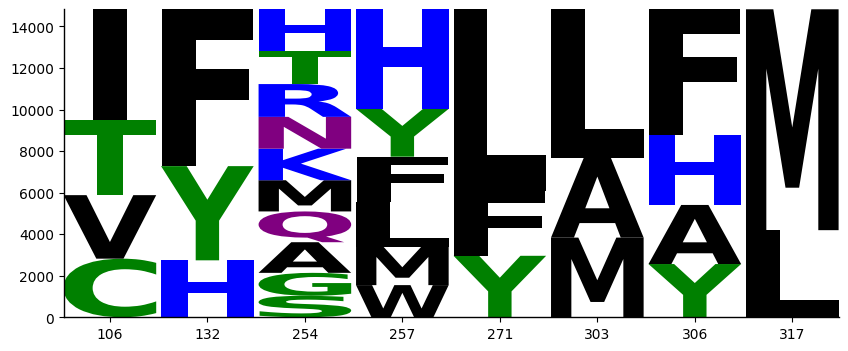

In [22]:
sequences = sequences_df["full_seq"]
sequences = sequences.apply(
    lambda x: "".join([x[i - 1] for i in config["pos_to_use"]])
)
plt.figure(figsize=(10, 4))
ax = plt.subplot(1, 1, 1)
count_matrix = lm.alignment_to_matrix(sequences=sequences, to_type="counts")
# create a logo
logo = lm.Logo(count_matrix, color_scheme="chemistry", ax=ax)
logo.style_spines(visible=False)
logo.style_spines(spines=["left", "bottom"], visible=True)
# set x-ticks to be the position in the sequence + 34
ax.set_xticks(range(len(config["pos_to_use"])))
ax.set_xticklabels([p + 34 for p in config["pos_to_use"]])
# logo.style_xticks(rotation=90, fmt="%d", anchor=0)